In [1]:
import pandas as pd
from pathlib import Path

data_folder = Path(".")
csv_files = sorted(data_folder.glob("*.csv"))
print("Number of csv file found:",len(csv_files))
for file in csv_files:
    print(file.name)

                   
                   


Number of csv file found: 6
ratings.csv
reviews.csv
subscribers.csv
titles.csv
watch_history.csv
watchlist.csv


In [2]:
#loading all six files into Python

all_dfs = {}

for file in csv_files:
    table_name = file.stem
    all_dfs[table_name] = pd.read_csv(file)
    rows,columns = all_dfs[table_name].shape
    print(f"{file.name}:{rows}rows,{columns}columns")

ratings.csv:130000rows,5columns
reviews.csv:110000rows,7columns
subscribers.csv:15000rows,14columns
titles.csv:9000rows,21columns
watch_history.csv:650000rows,10columns
watchlist.csv:65000rows,5columns


In [3]:
#Creating the basic profile summary


profile_summary= []

for table_name,df in all_dfs.items():
    profile_summary.append({"Table Name":table_name,"Row Count":df.shape[0],"Column Count":df.shape[1]})

profile_summary_df = pd.DataFrame(profile_summary)
profile_summary_df

,Table Name,Row Count,Column Count
0,ratings,130000,5
1,reviews,110000,7
2,subscribers,15000,14
3,titles,9000,21
4,watch_history,650000,10
5,watchlist,65000,5


In [4]:
#Checking column names and data types

for table_name,df in all_dfs.items():
    print(f"\n----{table_name.upper()}----")
    print(df.dtypes)


----RATINGS----
rating_id         int64
subscriber_id    object
title_id         object
rating            int64
rating_date      object
dtype: object

----REVIEWS----
review_id         int64
subscriber_id    object
title_id         object
review_text      object
sentiment        object
helpful_votes     int64
review_date      object
dtype: object

----SUBSCRIBERS----
subscriber_id         object
signup_date           object
country               object
region                object
age                    int64
gender                object
plan_type             object
monthly_price_usd    float64
household_size         int64
primary_device        object
payment_method        object
tenure_months          int64
is_active               bool
churn_date            object
dtype: object

----TITLES----
title_id                 object
title_name               object
type                     object
primary_genre            object
country                  object
language                 object
r

In [5]:
#checking missing values


missing_summary = []

for table_name,df in all_dfs.items():
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count/len(df)*100).round(2)

    table_missing = pd.DataFrame({
    "Table Name":table_name,"Column Name":df.columns,"Missing Count":missing_count,"Missing Percentage":missing_percentage})

    table_missing = table_missing[table_missing["Missing Count"]>0]

    missing_summary.append(table_missing)

missing_values_df = pd.concat(missing_summary,ignore_index=True)

missing_values_df

,Table Name,Column Name,Missing Count,Missing Percentage
0,subscribers,churn_date,11199,74.66
1,titles,license_expiry,1966,21.84


In [6]:
#checking exact duplicate rows

duplicate_summary = []

for table_name, df in all_dfs.items():
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (
        duplicate_count / len(df) * 100).round(2)

    duplicate_summary.append({
        "Table Name": table_name,
        "Duplicate Rows": duplicate_count,
        "Duplicate Percentage": duplicate_percentage})

duplicate_summary_df = pd.DataFrame(duplicate_summary)

duplicate_summary_df

,Table Name,Duplicate Rows,Duplicate Percentage
0,ratings,0,0.0
1,reviews,0,0.0
2,subscribers,0,0.0
3,titles,0,0.0
4,watch_history,0,0.0
5,watchlist,0,0.0


In [7]:
#Checking duplicate IDs


primary_keys = {
    "ratings": "rating_id",
    "reviews": "review_id",
    "subscribers": "subscriber_id",
    "titles": "title_id",
    "watch_history": "watch_id",
    "watchlist": "watchlist_id"}

key_duplicate_summary = []

for table_name, key_column in primary_keys.items():
    df = all_dfs[table_name]

    duplicate_mask = df[key_column].duplicated(keep=False)
    affected_rows = duplicate_mask.sum()
    duplicate_ids = df.loc[
        duplicate_mask, key_column].nunique()

    key_duplicate_summary.append({
        "Table Name": table_name,
        "ID Column": key_column,
        "Duplicate ID Values": duplicate_ids,
        "Affected Rows": affected_rows,
        "Affected Percentage": round(
            affected_rows / len(df) * 100, 2)})

key_duplicates_df = pd.DataFrame(key_duplicate_summary)

key_duplicates_df

,Table Name,ID Column,Duplicate ID Values,Affected Rows,Affected Percentage
0,ratings,rating_id,0,0,0.0
1,reviews,review_id,0,0,0.0
2,subscribers,subscriber_id,0,0,0.0
3,titles,title_id,0,0,0.0
4,watch_history,watch_id,0,0,0.0
5,watchlist,watchlist_id,0,0,0.0


#Exact duplicate rows: 0
#Duplicate primary ID values: 0
#Affected rows: 0

#This means all six primary-key columns are unique.

In [8]:
#Inspect date formats

date_columns = {
    "ratings": ["rating_date"],
    "reviews": ["review_date"],
    "subscribers": ["signup_date", "churn_date"],
    "titles": ["date_added", "license_expiry"],
    "watch_history": ["watch_date"],
    "watchlist": ["added_date"]}

for table_name, columns in date_columns.items():
    print(f"\n--- {table_name.upper()} ---")

    for column in columns:
        sample_values = (
            all_dfs[table_name][column]
            .dropna()
            .astype(str)
            .head(5)
            .tolist())

        print(f"{column}: {sample_values}")


--- RATINGS ---
rating_date: ['2026-02-06', '2025-03-21', '2024-05-26', '2026-05-22', '2026-05-16']

--- REVIEWS ---
review_date: ['2023-11-04', '2026-04-25', '2024-07-31', '2022-12-13', '2025-10-09']

--- SUBSCRIBERS ---
signup_date: ['2023-01-09', '2020-02-05', '2022-04-15', '2024-10-10', '2020-04-12']
churn_date: ['2022-12-08', '2021-12-15', '2024-10-19', '2020-07-22', '2026-05-08']

--- TITLES ---
date_added: ['2026-04-05', '2026-05-01', '2026-04-17', '2018-12-08', '2016-05-11']
license_expiry: ['2028-08-03', '2027-02-16', '2029-10-11', '2028-11-21', '2029-04-30']

--- WATCH_HISTORY ---
watch_date: ['2024-01-01', '2025-10-18', '2026-04-26', '2026-03-09', '2023-12-27']

--- WATCHLIST ---
added_date: ['2023-06-05', '2023-01-31', '2022-06-21', '2023-12-23', '2022-02-02']


In [9]:
#All eight date columns use the consistent format YYYY-MM-DD. We can safely convert them to pandas datetime.

In [10]:
#Convert and validate date columns

date_conversion_summary = []

for table_name, columns in date_columns.items():
    for column in columns:
        original_values = all_dfs[table_name][column].copy()

        converted_values = pd.to_datetime(
            original_values,
            format="%Y-%m-%d",
            errors="coerce")

        invalid_count = (
            original_values.notna() &
            converted_values.isna()).sum()

        all_dfs[table_name][column] = converted_values

        date_conversion_summary.append({
            "Table Name": table_name,
            "Date Column": column,
            "Invalid Dates": invalid_count,
            "New Data Type": str(
                all_dfs[table_name][column].dtype)})

date_conversion_df = pd.DataFrame(
    date_conversion_summary)

date_conversion_df

,Table Name,Date Column,Invalid Dates,New Data Type
0,ratings,rating_date,0,datetime64[ns]
1,reviews,review_date,0,datetime64[ns]
2,subscribers,signup_date,0,datetime64[ns]
3,subscribers,churn_date,0,datetime64[ns]
4,titles,date_added,0,datetime64[ns]
5,titles,license_expiry,0,datetime64[ns]
6,watch_history,watch_date,0,datetime64[ns]
7,watchlist,added_date,0,datetime64[ns]


All eight date columns were converted to datetime64[ns].
Invalid dates found: 0
Price and duration columns were already numeric.

In [11]:
#Flag invalid watch durations


#Checking whether any viewing session is longer than the content itself.


watch_history_df = all_dfs["watch_history"]

duration_outlier_mask = (
    watch_history_df["watch_duration_min"] >
    watch_history_df["content_duration_min"])

watch_history_df["duration_outlier_flag"] = (
    duration_outlier_mask)

duration_outlier_count = duration_outlier_mask.sum()

duration_outlier_percentage = round(
    duration_outlier_count /
    len(watch_history_df) * 100,
    2)

print(
    "Sessions longer than content:",
    duration_outlier_count)

print(
    "Affected percentage:",
    duration_outlier_percentage,
    "%")

duration_outliers_df = watch_history_df.loc[
    duration_outlier_mask,
    [
        "watch_id",
        "subscriber_id",
        "title_id",
        "content_duration_min",
        "watch_duration_min"]].copy()

duration_outliers_df["excess_minutes"] = (
    duration_outliers_df["watch_duration_min"] -
    duration_outliers_df["content_duration_min"])

duration_outliers_df.head(10)

Sessions longer than content: 0
Affected percentage: 0.0 %


,watch_id,subscriber_id,title_id,content_duration_min,watch_duration_min,excess_minutes


Sessions longer than the content: 0
Affected percentage: 0.0%
All 650,000 watch-history rows pass the duration rule.

In [12]:
#Checking referential integrity

valid_subscriber_ids = set(
    all_dfs["subscribers"]["subscriber_id"])

valid_title_ids = set(
    all_dfs["titles"]["title_id"])

invalid_subscriber_mask = (
    ~watch_history_df["subscriber_id"]
    .isin(valid_subscriber_ids))

invalid_title_mask = (
    ~watch_history_df["title_id"]
    .isin(valid_title_ids))

integrity_summary_df = pd.DataFrame({
    "Check": [
        "Invalid subscriber_id",
        "Invalid title_id"],
    "Broken Rows": [
        invalid_subscriber_mask.sum(),
        invalid_title_mask.sum()],
    "Broken Percentage": [
        round(
            invalid_subscriber_mask.mean() * 100,
            2),
        round(
            invalid_title_mask.mean() * 100,
            2)],
    "Unique Broken IDs": [
        watch_history_df.loc[
            invalid_subscriber_mask,
            "subscriber_id"
        ].nunique(),
        watch_history_df.loc[
            invalid_title_mask,
            "title_id"
        ].nunique()]})

integrity_summary_df

,Check,Broken Rows,Broken Percentage,Unique Broken IDs
0,Invalid subscriber_id,0,0.0,0
1,Invalid title_id,0,0.0,0


Invalid subscriber_id: 0
Invalid title_id: 0
Referential integrity is fully maintained in watch_history

In [13]:
#Specific Check 1 — Churn date after signup date

subscribers_df = all_dfs["subscribers"]

churned_mask = subscribers_df["churn_date"].notna()

invalid_churn_order_mask = (
    churned_mask &
    (
        subscribers_df["churn_date"] <=
        subscribers_df["signup_date"]
    )
)

total_churned = churned_mask.sum()

invalid_churn_order_count = (
    invalid_churn_order_mask.sum()
)

invalid_churn_order_percentage = round(
    invalid_churn_order_count /
    total_churned * 100,
    2
)

print("Total churned subscribers:", total_churned)

print(
    "Invalid churn-date order:",
    invalid_churn_order_count
)

print(
    "Percentage of churned subscribers affected:",
    invalid_churn_order_percentage,
    "%"
)

invalid_churn_order_df = subscribers_df.loc[
    invalid_churn_order_mask,
    [
        "subscriber_id",
        "signup_date",
        "churn_date",
        "is_active"
    ]
]

invalid_churn_order_df.head(10)

Total churned subscribers: 3801
Invalid churn-date order: 0
Percentage of churned subscribers affected: 0.0 %


,subscriber_id,signup_date,churn_date,is_active


Specific Check 1 passed:

Total churned subscribers: 3,801
Invalid date order: 0
All churn dates occur after signup dates.

In [14]:
#Specific Check 2 — Active subscribers with a churn date


active_mask = (
    subscribers_df["is_active"] == True
)

active_with_churn_mask = (
    active_mask &
    subscribers_df["churn_date"].notna()
)

total_active = active_mask.sum()

active_with_churn_count = (
    active_with_churn_mask.sum()
)

active_with_churn_percentage = round(
    active_with_churn_count /
    total_active * 100,
    2
)

print("Total active subscribers:", total_active)

print(
    "Active subscribers with a churn date:",
    active_with_churn_count
)

print(
    "Percentage of active subscribers affected:",
    active_with_churn_percentage,
    "%"
)

active_churn_mismatch_df = subscribers_df.loc[
    active_with_churn_mask,
    [
        "subscriber_id",
        "signup_date",
        "churn_date",
        "is_active"
    ]
]

active_churn_mismatch_df.head(10)

Total active subscribers: 11199
Active subscribers with a churn date: 0
Percentage of active subscribers affected: 0.0 %


,subscriber_id,signup_date,churn_date,is_active


Specific Check 2 passed:

Active subscribers: 11,199
Active subscribers with a churn date: 0
Therefore, the 11,199 missing churn_date values are expected—not data-quality errors.

Specific Check 3 — Validate completion_pct

Expected completion %=
watch (duration/content duration)*100
	

In [15]:
completion_check_df = watch_history_df[
    [
        "watch_id",
        "content_duration_min",
        "watch_duration_min",
        "completion_pct"
    ]
].copy()

completion_check_df["calculated_completion_pct"] = (
    completion_check_df["watch_duration_min"] /
    completion_check_df["content_duration_min"] *
    100
)

completion_check_df["difference"] = (
    completion_check_df["completion_pct"] -
    completion_check_df["calculated_completion_pct"]
).abs()

tolerance = 0.1

completion_mismatch_mask = (
    completion_check_df["difference"] > tolerance
)

completion_mismatch_count = (
    completion_mismatch_mask.sum()
)

completion_mismatch_percentage = round(
    completion_mismatch_count /
    len(completion_check_df) * 100,
    2
)

print(
    "Completion percentage mismatches:",
    completion_mismatch_count
)

print(
    "Affected percentage:",
    completion_mismatch_percentage,
    "%"
)

completion_check_df.loc[
    completion_mismatch_mask
].head(10)

Completion percentage mismatches: 1845
Affected percentage: 0.28 %


,watch_id,content_duration_min,watch_duration_min,completion_pct,calculated_completion_pct,difference
14,15,70,35.7,51.1,51.000000,0.100000
66,67,61,56.3,92.4,92.295082,0.104918
593,594,64,48.7,76.2,76.093750,0.106250
790,791,74,68.6,92.6,92.702703,0.102703
1311,1312,89,8.1,9.0,9.101124,0.101124
1472,1473,75,43.8,58.5,58.400000,0.100000
2098,2099,75,43.8,58.3,58.400000,0.100000
2247,2248,82,73.8,90.1,90.000000,0.100000
3315,3316,61,53.3,87.5,87.377049,0.122951
3748,3749,63,47.2,74.8,74.920635,0.120635


In [16]:
#Checking assess rounding differences

difference_summary = (
    completion_check_df["difference"]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
    .round(4)
)

difference_summary

count    650000.0000
mean          0.0294
std           0.0211
min           0.0000
50%           0.0265
90%           0.0579
95%           0.0696
99%           0.0885
max           0.1556
Name: difference, dtype: float64

In [17]:
tolerances = [0.1, 0.5, 1.0]

tolerance_summary = []

for value in tolerances:
    mismatch_count = (
        completion_check_df["difference"] > value
    ).sum()

    tolerance_summary.append({
        "Tolerance": value,
        "Mismatch Count": mismatch_count,
        "Mismatch Percentage": round(
            mismatch_count /
            len(completion_check_df) * 100,
            4
        )
    })

tolerance_summary_df = pd.DataFrame(
    tolerance_summary
)

tolerance_summary_df

,Tolerance,Mismatch Count,Mismatch Percentage
0,0.1,1845,0.2838
1,0.5,0,0.0000
2,1.0,0,0.0000


#this confirms our interpretation:

At tolerance 0.1: 1,845 apparent mismatches due to rounding
At tolerance 0.5: 0 mismatches
At tolerance 1.0: 0 mismatches

In [18]:
#Specific Check 4 — Validate sentiment values


reviews_df = all_dfs["reviews"]

allowed_sentiments = [
    "Positive",
    "Neutral",
    "Negative"
]

invalid_sentiment_mask = (
    ~reviews_df["sentiment"].isin(
        allowed_sentiments
    )
)

print(
    "Invalid sentiment rows:",
    invalid_sentiment_mask.sum()
)

print(
    "Affected percentage:",
    round(
        invalid_sentiment_mask.mean() * 100,
        2
    ),
    "%"
)

sentiment_counts_df = (
    reviews_df["sentiment"]
    .value_counts(dropna=False)
    .rename_axis("Sentiment")
    .reset_index(name="Row Count")
)

sentiment_counts_df

Invalid sentiment rows: 0
Affected percentage: 0.0 %


,Sentiment,Row Count
0,Positive,75007
1,Neutral,22759
2,Negative,12234


Specific Check 4 passed:

Positive: 75,007
Neutral: 22,759
Negative: 12,234
Invalid sentiment values: 0

In [19]:
#Specific Check 5 — Validate watchlist links

watchlist_df = all_dfs["watchlist"]

invalid_watchlist_subscriber_mask = (
    ~watchlist_df["subscriber_id"]
    .isin(valid_subscriber_ids)
)

invalid_watchlist_title_mask = (
    ~watchlist_df["title_id"]
    .isin(valid_title_ids)
)

watchlist_integrity_df = pd.DataFrame({
    "Check": [
        "Invalid subscriber_id",
        "Invalid title_id"
    ],
    "Broken Rows": [
        invalid_watchlist_subscriber_mask.sum(),
        invalid_watchlist_title_mask.sum()
    ],
    "Broken Percentage": [
        round(
            invalid_watchlist_subscriber_mask.mean()
            * 100,
            2
        ),
        round(
            invalid_watchlist_title_mask.mean()
            * 100,
            2
        )
    ],
    "Unique Broken IDs": [
        watchlist_df.loc[
            invalid_watchlist_subscriber_mask,
            "subscriber_id"
        ].nunique(),
        watchlist_df.loc[
            invalid_watchlist_title_mask,
            "title_id"
        ].nunique()
    ]
})

watchlist_integrity_df

,Check,Broken Rows,Broken Percentage,Unique Broken IDs
0,Invalid subscriber_id,0,0.0,0
1,Invalid title_id,0,0.0,0


Specific Check 5 passed:

Invalid watchlist subscriber IDs: 0
Invalid watchlist title IDs: 0
All 65,000 watchlist entries link to valid parent records.

In [20]:
#Specific Check 6 — Active subscribers with short tenure


short_tenure_threshold = 3

short_tenure_active_mask = (
    (subscribers_df["is_active"] == True) &
    (
        subscribers_df["tenure_months"] <=
        short_tenure_threshold
    )
)

short_tenure_active_count = (
    short_tenure_active_mask.sum()
)

short_tenure_active_percentage = round(
    short_tenure_active_count /
    total_active * 100,
    2
)

print(
    "Short-tenure threshold:",
    short_tenure_threshold,
    "months"
)

print(
    "Active subscribers with short tenure:",
    short_tenure_active_count
)

print(
    "Percentage of active subscribers:",
    short_tenure_active_percentage,
    "%"
)

short_tenure_active_df = subscribers_df.loc[
    short_tenure_active_mask,
    [
        "subscriber_id",
        "signup_date",
        "tenure_months",
        "plan_type",
        "is_active"
    ]
].sort_values("tenure_months")

short_tenure_active_df.head(10)


Short-tenure threshold: 3 months
Active subscribers with short tenure: 640
Percentage of active subscribers: 5.71 %


,subscriber_id,signup_date,tenure_months,plan_type,is_active
14943,SUB114943,2026-04-29,1,Premium,True
14941,SUB114941,2026-05-13,1,Premium,True
14918,SUB114918,2026-04-22,1,Basic with Ads,True
14901,SUB114901,2026-05-19,1,Premium,True
14857,SUB114857,2026-05-01,1,Standard,True
358,SUB100358,2026-04-24,1,Premium,True
326,SUB100326,2026-04-30,1,Premium,True
279,SUB100279,2026-05-31,1,Standard,True
277,SUB100277,2026-04-05,1,Basic with Ads,True
270,SUB100270,2026-05-05,1,Premium,True


The short-tenure check ran successfully:

Threshold: 3 months or less
Active subscribers affected: 5.71%
This is informational and not a data-quality error, as stated in the PRD.

In [21]:
short_tenure_active_count

np.int64(640)

640 active subscribers have tenure of three months or less, representing 5.71% of active subscribers.

In [22]:
#Final missing-value validation
titles_df = all_dfs["titles"]

missing_license_mask = (
    titles_df["license_expiry"].isna()
)

original_missing_expiry = (
    missing_license_mask &
    (titles_df["is_original"] == True)
).sum()

licensed_missing_expiry = (
    missing_license_mask &
    (titles_df["is_original"] == False)
).sum()

license_missing_validation_df = pd.DataFrame({
    "Check": [
        "Original titles with missing expiry",
        "Non-original titles with missing expiry"
    ],
    "Count": [
        original_missing_expiry,
        licensed_missing_expiry
    ]
})

license_missing_validation_df

,Check,Count
0,Original titles with missing expiry,1966
1,Non-original titles with missing expiry,0


# StreamFlix Phase 1 — Data Quality Report

## Objective

The purpose of Phase 1 was to profile, clean, and validate the six StreamFlix datasets before conducting further analysis. The assessment covered 979,000 records across ratings, reviews, subscribers, titles, watch history, and watchlist data.

## Dataset Profile

| Dataset           |    Rows | Columns |
| ----------------- | ------: | ------: |
| ratings.csv       | 130,000 |       5 |
| reviews.csv       | 110,000 |       7 |
| subscribers.csv   |  15,000 |      14 |
| titles.csv        |   9,000 |      21 |
| watch_history.csv | 650,000 |      10 |
| watchlist.csv     |  65,000 |       5 |

## Key Findings

**Missing values:** Only two columns contained missing values. `churn_date` had 11,199 missing values (74.66%), all belonging to active subscribers; therefore, these blanks are expected. `license_expiry` had 1,966 missing values (21.84%), all belonging to StreamFlix-original titles; therefore, these blanks are also valid. No imputation or deletion was required.

**Duplicates and keys:** No exact duplicate rows were found in any dataset. All primary identifiers—`rating_id`, `review_id`, `subscriber_id`, `title_id`, `watch_id`, and `watchlist_id`—were unique.

**Data types:** Eight date columns were initially stored as text. These were converted to `datetime64[ns]` using the `YYYY-MM-DD` format. No invalid date values were found during conversion. Duration and price columns were already numeric.

**Watch-duration validation:** No viewing sessions had a `watch_duration_min` greater than `content_duration_min`. Therefore, all 650,000 watch-history records passed the duration rule.

**Referential integrity:** Every `subscriber_id` and `title_id` in both `watch_history.csv` and `watchlist.csv` matched valid records in their respective parent tables. No orphan records were found.

## Specific Business-Rule Checks

* All 3,801 churned subscribers had a `churn_date` later than their `signup_date`.
* All 11,199 active subscribers had a blank `churn_date`; no active/churn-date mismatches were found.
* The stored `completion_pct` values were compared with `watch_duration_min ÷ content_duration_min × 100`. The maximum difference was 0.1556 percentage points. Using a documented rounding tolerance of 0.5 percentage points, no mismatches were found.
* Review sentiment contained only the permitted categories: Positive (75,007), Neutral (22,759), and Negative (12,234).
* A short-tenure threshold of three months or less was used. There were 640 active short-tenure subscribers, representing 5.71% of active subscribers. As stated in the requirements, this is informational and not a data-quality error.

## Conclusion

The StreamFlix datasets passed all required Phase 1 quality checks. No duplicate keys, invalid dates, impossible watch durations, broken relationships, invalid sentiment values, or business-rule violations were identified. The observed missing values are structurally expected and should remain unchanged. Based on these checks, the data is suitable for the next phase of analysis.


# Phase 2 — Exploratory Data Analysis

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

from pathlib import Path

chart_folder = Path("phase2_Charts")
chart_folder.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

print("phase2 chart setup completed.")
print("PNG folder:",chart_folder)

phase2 chart setup completed.
PNG folder: phase2_Charts


In [25]:
#chart setup is completed ,our PNG folder name is phase2_charts and variable name is chart_folder


#Chart 1 — Calculate monthly viewing volume


monthly_viewing_volume = (
    watch_history_df
    .groupby(
        watch_history_df["watch_date"]
        .dt.to_period("M")
    )["watch_id"]
    .count()
    .reset_index(name="viewing_sessions"))

monthly_viewing_volume["watch_date"] = (
    monthly_viewing_volume["watch_date"]
    .dt.to_timestamp())

busiest_month = monthly_viewing_volume.loc[
    monthly_viewing_volume[
        "viewing_sessions"
    ].idxmax()
]

print(
    "Timeline:",
    monthly_viewing_volume["watch_date"].min(),
    "to",
    monthly_viewing_volume["watch_date"].max()
)

print(
    "Busiest month:",
    busiest_month["watch_date"].strftime("%B %Y")
)

print(
    "Sessions in busiest month:",
    busiest_month["viewing_sessions"]
)

monthly_viewing_volume.head(10)

Timeline: 2017-03-01 00:00:00 to 2026-05-01 00:00:00
Busiest month: May 2026
Sessions in busiest month: 224696


,watch_date,viewing_sessions
0,2017-03-01,1
1,2017-04-01,1
2,2017-05-01,1
3,2017-07-01,1
4,2017-09-01,2
5,2017-10-01,1
6,2017-11-01,6
7,2017-12-01,1
8,2018-01-01,4
9,2018-02-01,3


In [27]:
all_dfs["watch_history"]


,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,duration_outlier_flag
0,1,SUB107630,TTL205207,2024-01-01,Smart TV,East Asia,888,826.7,93.1,True,False
1,2,SUB114773,TTL204889,2025-10-18,Mobile,South Asia,2340,1866.4,79.8,False,False
2,3,SUB106013,TTL206882,2026-04-26,Mobile,Latin America,656,75.0,11.4,False,False
3,4,SUB100939,TTL208849,2026-03-09,Mobile,North America,500,493.2,98.6,True,False
4,5,SUB107223,TTL202529,2023-12-27,Tablet,North America,141,94.6,67.1,False,False
...,...,...,...,...,...,...,...,...,...,...,...
649995,649996,SUB113946,TTL207486,2025-07-13,Mobile,Europe,444,8.6,1.9,False,False
649996,649997,SUB108172,TTL200072,2026-05-22,Smart TV,Latin America,420,338.3,80.5,False,False
649997,649998,SUB108092,TTL204011,2025-01-25,Streaming Stick,South Asia,261,47.4,18.2,False,False
649998,649999,SUB114820,TTL204762,2026-04-13,Tablet,North America,77,11.6,15.0,False,False


In [32]:
watch_history_df["watch_month"] = (watch_history_df["watch_date"].dt.to_period("M"))

watch_history_df[["watch_date","watch_month"]].head()

monthly_viewing_volume = (watch_history_df.groupby("watch_month").size()
                          .reset_index(name="viewing_sessions"))

monthly_viewing_volume = (monthly_viewing_volume.sort_values("watch_month"))

monthly_viewing_volume.head(10)

#adding missing month

full_month_range = pd.period_range(
    start=monthly_viewing_volume["watch_month"].min(),
    end=monthly_viewing_volume["watch_month"].max(),
    freq="M")

monthly_viewing_volume = (
    monthly_viewing_volume
    .set_index("watch_month")
    .reindex(full_month_range, fill_value=0)
    .rename_axis("watch_month")
    .reset_index())

monthly_viewing_volume.head(12)

#busiest month

busiest_month = monthly_viewing_volume.loc[
    monthly_viewing_volume[
        "viewing_sessions"].idxmax()]

print("Busiest month:",
    busiest_month["watch_month"].strftime("%B %Y"))

print("Viewing sessions:",
    busiest_month["viewing_sessions"])

top_5_months = (
    monthly_viewing_volume
    .sort_values(
        "viewing_sessions",
        ascending=False).head(5))

top_5_months

Busiest month: May 2026
Viewing sessions: 224696


,watch_month,viewing_sessions
110,2026-05,224696
109,2026-04,90383
108,2026-03,55665
107,2026-02,33795
106,2026-01,27970


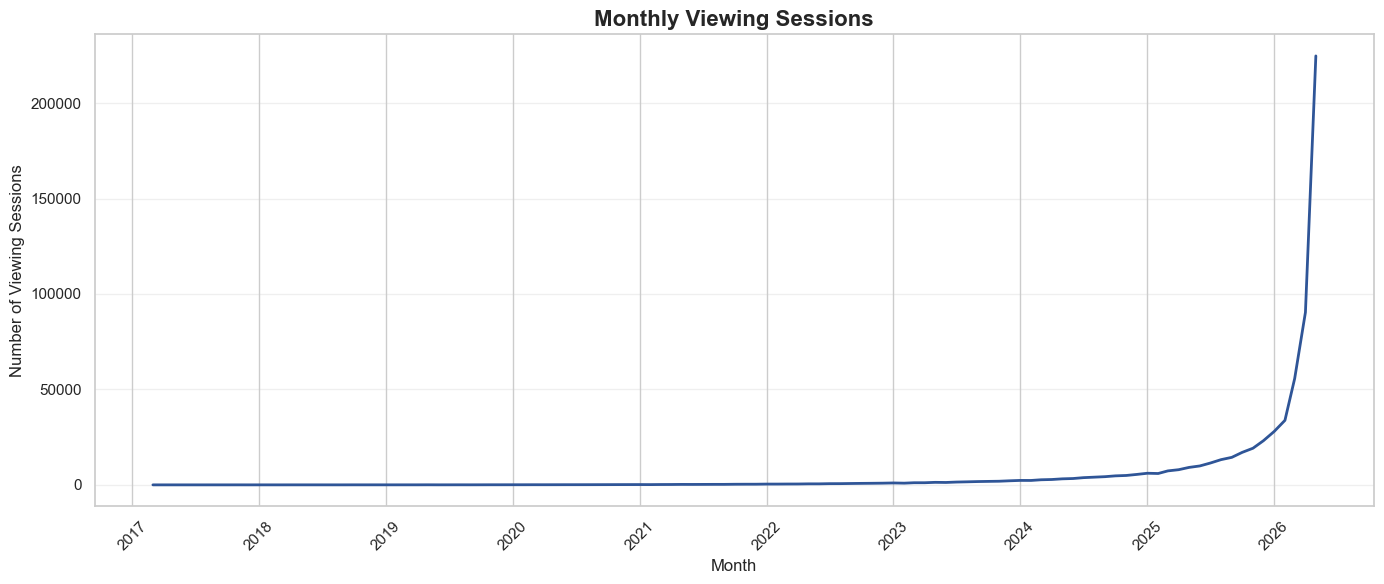

In [33]:
#Chart 1 Creating the basic line chart

monthly_viewing_volume["month_start"] = (
    monthly_viewing_volume["watch_month"]
    .dt.to_timestamp())

plt.figure(figsize=(14, 6))

plt.plot(monthly_viewing_volume["month_start"],
    monthly_viewing_volume["viewing_sessions"],
    color="#2F5597",
    linewidth=2)

plt.title("Monthly Viewing Sessions",
    fontsize=16,
    fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

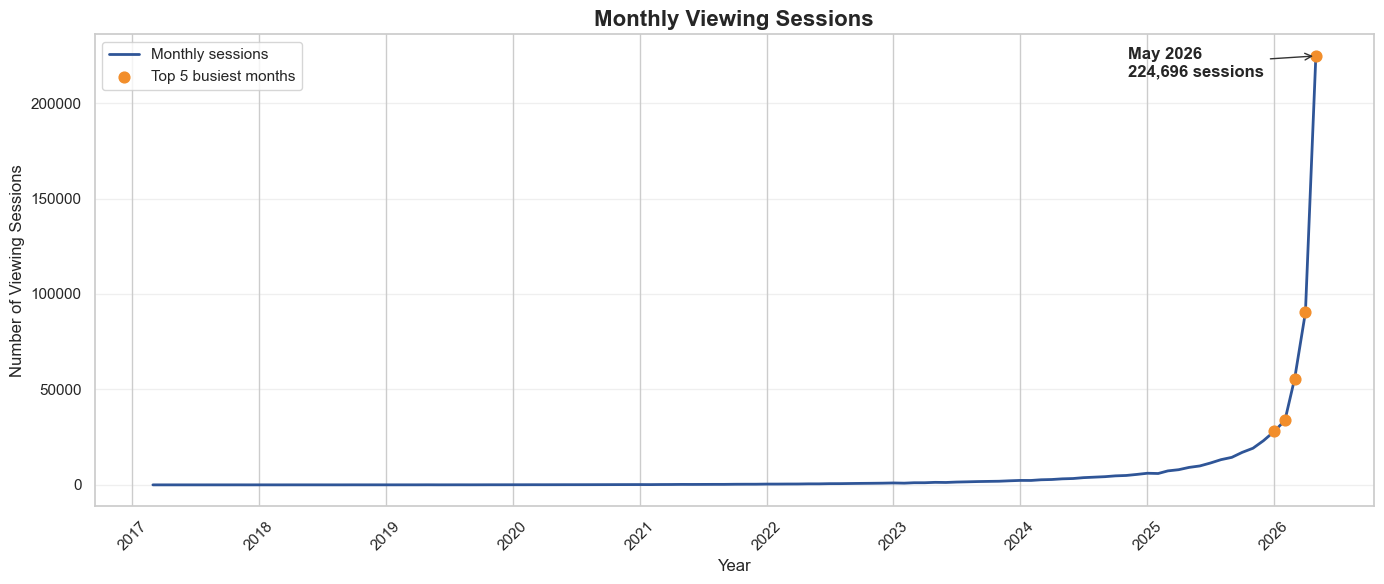

In [39]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Full monthly timeline
ax.plot(
    monthly_viewing_volume["month_start"],
    monthly_viewing_volume["viewing_sessions"],
    color="#2F5597",
    linewidth=2,
    label="Monthly sessions"
)

# Highlight top five months
ax.scatter(
    top_5_dates,
    top_5_months["viewing_sessions"],
    color="#F28E2B",
    s=60,
    label="Top 5 busiest months",
    zorder=3
)

# Highlight and label the busiest month
ax.annotate(
    "May 2026\n224,696 sessions",
    xy=(
        busiest_date,
        busiest_month["viewing_sessions"]
    ),
    xytext=(-135, -15),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "#333333"
    },
    fontweight="bold"
)

ax.set_title(
    "Monthly Viewing Sessions",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Viewing Sessions")

# Display one readable tick per year
ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()

fig.savefig(
    chart_folder /
    "01_monthly_viewing_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 1 Observation — Monthly Viewing Volume

Viewing activity remained relatively low through 2022, increased gradually from 2023, and accelerated sharply during 2025 and early 2026. May 2026 was the busiest month with 224,696 sessions—approximately 148.6% higher than April 2026, which recorded 90,383 sessions. All five busiest months occurred between January and May 2026, showing that viewing activity was heavily concentrated in the most recent period.


In [40]:
#Chart 2 — Step 1: Calculate monthly watch hours


monthly_watch_hours = (
    watch_history_df
    .groupby("watch_month")[
        "watch_duration_min"].sum().reset_index(name="watch_duration_minutes"))

monthly_watch_hours["watch_hours"] = (
    monthly_watch_hours[
        "watch_duration_minutes"] / 60)

monthly_watch_hours.head(10)

,watch_month,watch_duration_minutes,watch_hours
0,2017-03,286.4,4.773333
1,2017-04,264.0,4.400000
2,2017-05,865.0,14.416667
3,2017-07,84.8,1.413333
4,2017-09,156.6,2.610000
5,2017-10,117.0,1.950000
6,2017-11,526.5,8.775000
7,2017-12,445.1,7.418333
8,2018-01,3991.8,66.530000
9,2018-02,2813.5,46.891667


In [42]:
#Adding missing months


monthly_watch_hours = (monthly_watch_hours
    .set_index("watch_month")
    .reindex(
        full_month_range,
        fill_value=0)
    .rename_axis("watch_month")
    .reset_index())

monthly_watch_hours.head(12)

,watch_month,watch_duration_minutes,watch_hours
0,2017-03,286.4,4.773333
1,2017-04,264.0,4.400000
2,2017-05,865.0,14.416667
3,2017-06,0.0,0.000000
4,2017-07,84.8,1.413333
5,2017-08,0.0,0.000000
6,2017-09,156.6,2.610000
7,2017-10,117.0,1.950000
8,2017-11,526.5,8.775000
9,2017-12,445.1,7.418333


In [43]:
#Creating year and month fields


monthly_watch_hours["year"] = (
    monthly_watch_hours["watch_month"]
    .dt.year)

monthly_watch_hours["month_number"] = (
    monthly_watch_hours["watch_month"]
    .dt.month)

monthly_watch_hours["month_name"] = (
    monthly_watch_hours["watch_month"]
    .dt.strftime("%b"))

monthly_watch_hours[["watch_month",
        "year",
        "month_number",
        "month_name",
        "watch_hours"]].tail(12)

,watch_month,year,month_number,month_name,watch_hours
99,2025-06,2025,6,Jun,5.013146e+04
100,2025-07,2025,7,Jul,5.868275e+04
101,2025-08,2025,8,Aug,6.670937e+04
102,2025-09,2025,9,Sep,7.176683e+04
103,2025-10,2025,10,Oct,8.526854e+04
104,2025-11,2025,11,Nov,9.856612e+04
105,2025-12,2025,12,Dec,1.180307e+05
106,2026-01,2026,1,Jan,1.435220e+05
107,2026-02,2026,2,Feb,1.745655e+05
108,2026-03,2026,3,Mar,2.860884e+05


In [44]:
#Preparing the comparison years

comparison_years = [
    2024,
    2025,
    2026]

yoy_watch_hours = (
    monthly_watch_hours[
        monthly_watch_hours["year"]
        .isin(comparison_years)].copy())

#available months and totals

year_coverage = (
    yoy_watch_hours
    .groupby("year")
    .agg(
        months_available=(
            "month_number",
            "count"
        ),
        total_watch_hours=(
            "watch_hours",
            "sum"
        )
    )
    .reset_index()
)

year_coverage[
    "total_watch_hours"
] = (
    year_coverage[
        "total_watch_hours"
    ].round(2)
)

year_coverage

,year,months_available,total_watch_hours
0,2024,12,223994.05
1,2025,12,733939.06
2,2026,5,2225299.02


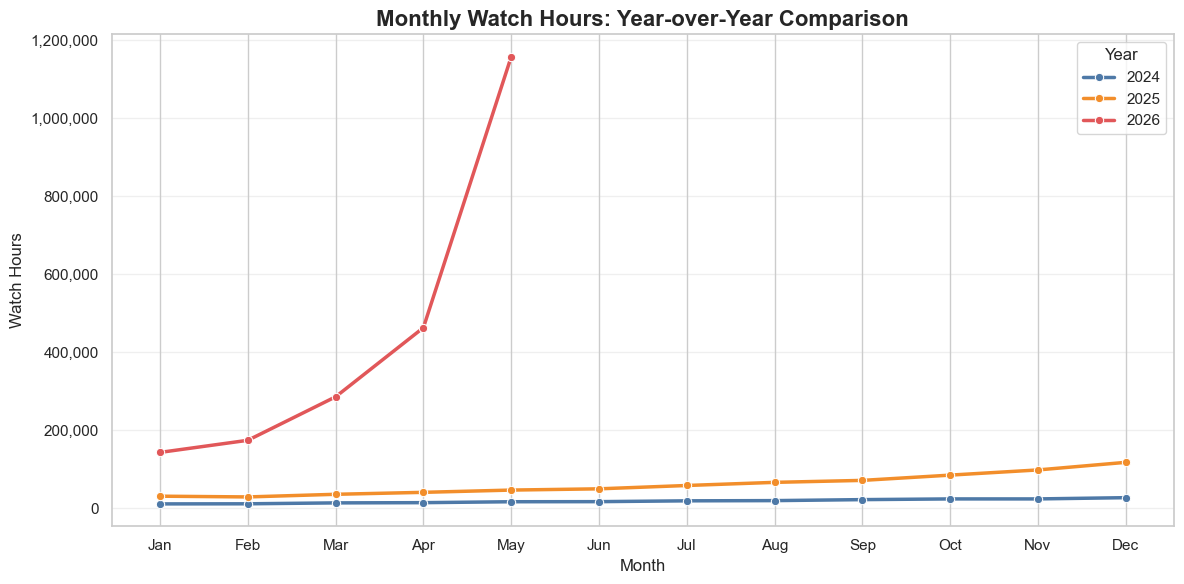

In [45]:
#Creating and saving the YoY chart

from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=yoy_watch_hours,
    x="month_number",
    y="watch_hours",
    hue="year",
    marker="o",
    linewidth=2.5,
    palette={
        2024: "#4E79A7",
        2025: "#F28E2B",
        2026: "#E15759"
    },
    ax=ax
)

ax.set_title(
    "Monthly Watch Hours: Year-over-Year Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Watch Hours")

ax.set_xticks(range(1, 13))

ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
])

ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Year")

fig.tight_layout()

fig.savefig(
    chart_folder /
    "02_monthly_watch_hours_yoy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
#Calculating comparable January–May totals

jan_to_may_data = yoy_watch_hours[
    yoy_watch_hours["month_number"] <= 5]

jan_to_may_summary = (
    jan_to_may_data
    .groupby("year")["watch_hours"]
    .sum()
    .reset_index())

jan_to_may_summary["yoy_growth_pct"] = (
    jan_to_may_summary["watch_hours"]
    .pct_change() * 100)

jan_to_may_summary = (jan_to_may_summary.round(2))

jan_to_may_summary

,year,watch_hours,yoy_growth_pct
0,2024,69018.93,NaN
1,2025,184783.25,167.73
2,2026,2225299.02,1104.28


### Chart 2 Observation — Monthly Watch Hours Trend

From January through May, total watch hours increased from 69,018.93 hours in 2024 to 184,783.25 hours in 2025, representing year-over-year growth of 167.73%. During the same five-month period in 2026, watch hours reached 2,225,299.02—an increase of 1,104.28% compared with 2025. The 2026 line rises especially sharply from March to May, with May reaching approximately 1.16 million watch hours.


In [47]:
#Chart 3 — Step 1- Join watch history with genres


genre_watch_data = (
    watch_history_df[
        [
            "watch_id",
            "title_id",
            "watch_duration_min"
        ]
    ]
    .merge(
        titles_df[
            [
                "title_id",
                "primary_genre"
            ]
        ],
        on="title_id",
        how="left",
        validate="many_to_one"
    )
)

#validating joins

print(
    "Watch-history rows:",
    len(watch_history_df)
)

print(
    "Rows after joining:",
    len(genre_watch_data)
)

print(
    "Rows with missing genre:",
    genre_watch_data[
        "primary_genre"
    ].isna().sum()
)

genre_watch_data.head()

Watch-history rows: 650000
Rows after joining: 650000
Rows with missing genre: 0


,watch_id,title_id,watch_duration_min,primary_genre
0,1,TTL205207,826.7,Comedy
1,2,TTL204889,1866.4,Drama
2,3,TTL206882,75.0,Comedy
3,4,TTL208849,493.2,Horror
4,5,TTL202529,94.6,Action


In [48]:
#Chart3-Step 2: Calculate watch hours by genre


genre_watch_hours = (
    genre_watch_data
    .groupby("primary_genre")[
        "watch_duration_min"
    ]
    .sum()
    .reset_index(
        name="watch_duration_minutes"
    )
)

#converting minutes into hrs

genre_watch_hours["watch_hours"] = (
    genre_watch_hours[
        "watch_duration_minutes"
    ] / 60
)


#calculating each genre's share

total_genre_watch_hours = (
    genre_watch_hours[
        "watch_hours"
    ].sum()
)

genre_watch_hours["share_percentage"] = (
    genre_watch_hours["watch_hours"] /
    total_genre_watch_hours * 100
)


#sorting and round results

genre_watch_hours = (
    genre_watch_hours
    .sort_values(
        "watch_hours",
        ascending=False
    )
)

genre_watch_hours[
    [
        "primary_genre",
        "watch_hours",
        "share_percentage"
    ]
].round(2)




,primary_genre,watch_hours,share_percentage
5,Drama,501884.47,15.06
2,Comedy,423149.05,12.69
0,Action,393171.92,11.79
15,Thriller,307024.66,9.21
4,Documentary,291216.90,8.74
3,Crime,237435.84,7.12
12,Romance,214332.30,6.43
1,Animation,180093.94,5.40
13,Sci-Fi,154332.21,4.63
7,Horror,138033.61,4.14


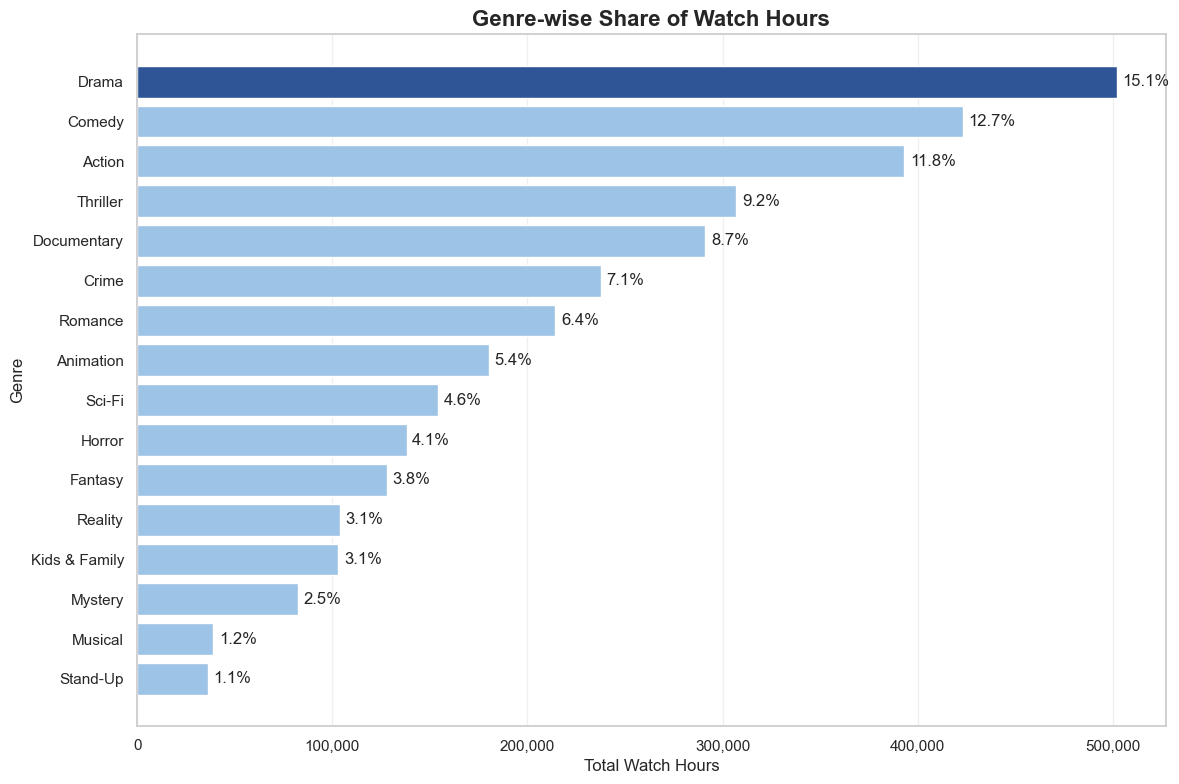

In [49]:
#Chart3-Creating and save the genre chart



genre_plot_data = (
    genre_watch_hours
    .sort_values(
        "watch_hours",
        ascending=True
    )
)

bar_colors = [
    "#2F5597"
    if genre == "Drama"
    else "#9DC3E6"
    for genre in genre_plot_data[
        "primary_genre"
    ]
]


fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    genre_plot_data["primary_genre"],
    genre_plot_data["watch_hours"],
    color=bar_colors
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in genre_plot_data[
            "share_percentage"
        ]
    ],
    padding=4
)



ax.set_title(
    "Genre-wise Share of Watch Hours",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Total Watch Hours")
ax.set_ylabel("Genre")

ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", visible=False)

fig.tight_layout()

fig.savefig(
    chart_folder /
    "03_genre_watch_hours_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Drama generated the highest watch time with 501,884.47 hours, representing 15.06% of total viewing. Comedy (12.69%) and Action (11.79%) ranked second and third; together, the top three genres contributed 39.54% of all watch hours. Musical and Stand-Up had the smallest shares at 1.17% and 1.09%, indicating substantially lower engagement than the leading genres.


In [ ]:
#Chart 4: Content Type Split—Movies vs. TV Shows


#Check the content-type values

## 4. Content Type Split — Movies vs. TV Shows

In [51]:
titles_df.columns.tolist()

['title_id',
 'title_name',
 'type',
 'primary_genre',
 'country',
 'language',
 'release_year',
 'date_added',
 'maturity_rating',
 'seasons',
 'content_duration_min',
 'is_original',
 'license_type',
 'director',
 'cast',
 'quality_score',
 'popularity_score',
 'license_cost_usd',
 'license_expiry',
 'total_watch_hours',
 'total_plays']

In [53]:
titles_df["type"].value_counts(dropna=False)

type
Movie      5336
TV Show    3664
Name: count, dtype: int64

#We have exactly two valid categories:

Movie: 5,336 titles
TV Show: 3,664 titles
No missing values
However, the required donut chart must show the share of watch hours, not the number of titles.

In [54]:
#Joining content type with viewing data

content_type_watch_data = watch_history_df[
    ["watch_id", "title_id", "watch_duration_min"]
].merge(
    titles_df[["title_id", "type"]],
    on="title_id",
    how="left",
    validate="many_to_one"
)

print("Watch-history rows:", len(watch_history_df))
print("Rows after joining:", len(content_type_watch_data))
print("Rows with missing type:", content_type_watch_data["type"].isna().sum())

content_type_watch_data.head()

Watch-history rows: 650000
Rows after joining: 650000
Rows with missing type: 0


,watch_id,title_id,watch_duration_min,type
0,1,TTL205207,826.7,TV Show
1,2,TTL204889,1866.4,TV Show
2,3,TTL206882,75.0,TV Show
3,4,TTL208849,493.2,TV Show
4,5,TTL202529,94.6,Movie


In [55]:
#Calculating watch hours by content type

content_type_summary = (
    content_type_watch_data
    .groupby("type", as_index=False)["watch_duration_min"]
    .sum()
    .rename(columns={"watch_duration_min": "watch_duration_minutes"})
)

content_type_summary["watch_hours"] = (
    content_type_summary["watch_duration_minutes"] / 60
)

content_type_summary["share_percentage"] = (
    content_type_summary["watch_hours"]
    / content_type_summary["watch_hours"].sum()
    * 100
)

content_type_summary

,type,watch_duration_minutes,watch_hours,share_percentage
0,Movie,27051528.6,4.508588e+05,13.525219
1,TV Show,172956535.4,2.882609e+06,86.474781


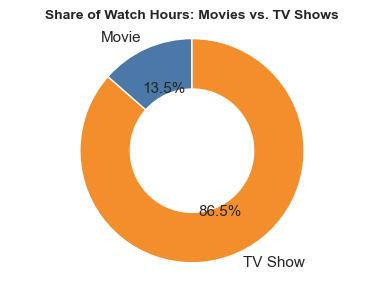

In [58]:
#Creating and saving the donut chart


plt.figure(figsize=(4, 3))

plt.pie(
    content_type_summary["watch_hours"],
    labels=content_type_summary["type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F28E2B"],
    wedgeprops={"width": 0.45, "edgecolor": "white"},
    textprops={"fontsize": 11}
)

plt.title(
    "Share of Watch Hours: Movies vs. TV Shows",
    fontsize=10,
    fontweight="bold"
)

plt.axis("equal")
plt.tight_layout()

plt.savefig(
    chart_folder / "04_content_type_watch_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

TV Shows generated approximately 2.88 million watch hours, accounting for 86.5% of total viewing time. Movies generated approximately 450,859 watch hours and represented only 13.5% of the total. Therefore, viewers spent about 6.4 times more time watching TV Shows than Movies.


In [ ]:
#Chart 5: Top 10 Countries by Watch Hours.

In [ ]:
#Checking country values

### 5. Top 10 Countries by Watch Hours

In [59]:
print("Unique countries:", titles_df["country"].nunique())
print("Missing country values:", titles_df["country"].isna().sum())

titles_df["country"].value_counts(dropna=False).head(10)

Unique countries: 20
Missing country values: 0


country
United States     2265
India             1163
United Kingdom     769
South Korea        636
Japan              556
Brazil             447
Mexico             441
Spain              419
France             377
Germany            330
Name: count, dtype: int64

In [60]:
#Joining country with viewing data

country_watch_data = watch_history_df[
    ["watch_id", "title_id", "watch_duration_min"]].merge(
    titles_df[["title_id", "country"]],
    on="title_id",
    how="left",
    validate="many_to_one")

print("Watch-history rows:", len(watch_history_df))
print("Rows after joining:", len(country_watch_data))
print("Rows with missing country:", country_watch_data["country"].isna().sum())

country_watch_data.head()

Watch-history rows: 650000
Rows after joining: 650000
Rows with missing country: 0


,watch_id,title_id,watch_duration_min,country
0,1,TTL205207,826.7,Mexico
1,2,TTL204889,1866.4,Indonesia
2,3,TTL206882,75.0,India
3,4,TTL208849,493.2,India
4,5,TTL202529,94.6,Japan


In [61]:
#Calculating the top 10 countries by watch hours

country_watch_summary = (
    country_watch_data
    .groupby("country", as_index=False)["watch_duration_min"]
    .sum()
)

country_watch_summary["watch_hours"] = (
    country_watch_summary["watch_duration_min"] / 60
)

country_watch_summary["share_percentage"] = (
    country_watch_summary["watch_hours"]
    / country_watch_summary["watch_hours"].sum()
    * 100
)

top_10_countries = (
    country_watch_summary
    .sort_values("watch_hours", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_10_countries

,country,watch_duration_min,watch_hours,share_percentage
0,United States,49361080.8,822684.680000,24.679545
1,India,27860265.4,464337.756667,13.929571
2,United Kingdom,16976783.4,282946.390000,8.488049
3,South Korea,13408584.2,223476.403333,6.704022
4,Japan,12427851.9,207130.865000,6.213675
5,Brazil,10581216.1,176353.601667,5.290395
6,Mexico,9430611.5,157176.858333,4.715116
7,Spain,8619383.8,143656.396667,4.309518
8,France,6900705.7,115011.761667,3.450214
9,Canada,6424377.1,107072.951667,3.212059


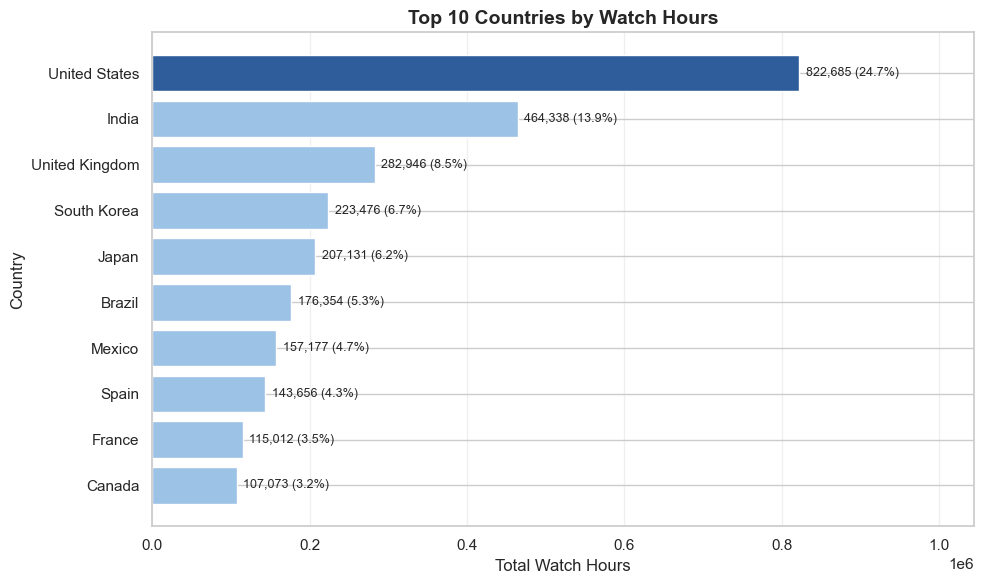

In [62]:
#Chart5: Creating and saving the horizontal bar chart

country_plot_data = top_10_countries.sort_values(
    "watch_hours",
    ascending=True
)

bar_colors = ["#9CC2E5"] * len(country_plot_data)
bar_colors[-1] = "#2F5D9B"

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    country_plot_data["country"],
    country_plot_data["watch_hours"],
    color=bar_colors
)

for bar, hours, percentage in zip(
    bars,
    country_plot_data["watch_hours"],
    country_plot_data["share_percentage"]
):
    ax.text(
        hours + top_10_countries["watch_hours"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{hours:,.0f} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Top 10 Countries by Watch Hours",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Total Watch Hours")
ax.set_ylabel("Country")
ax.set_xlim(0, top_10_countries["watch_hours"].max() * 1.27)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    chart_folder / "05_top_10_countries_watch_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




### Observation

The United States generated the highest viewing time with approximately 822,685 watch hours, representing 24.7% of total watch time. India ranked second with 464,338 hours (13.9%), while the United Kingdom ranked third with 282,946 hours (8.5%). Together, these three countries contributed approximately 47.1% of total viewing, showing that almost half of all watch hours came from the three leading markets.


In [ ]:
#Chart 6: Subscriber Plan Distribution.

#Checking subscriber plan categories

In [63]:
print("Unique plan types:", subscribers_df["plan_type"].nunique())
print("Missing plan values:", subscribers_df["plan_type"].isna().sum())

subscribers_df["plan_type"].value_counts(dropna=False)

Unique plan types: 3
Missing plan values: 0


plan_type
Standard          6100
Basic with Ads    4458
Premium           4442
Name: count, dtype: int64

In [64]:
#Calculating plan percentages

plan_summary = (
    subscribers_df["plan_type"]
    .value_counts()
    .rename_axis("plan_type")
    .reset_index(name="subscriber_count")
)

plan_summary["share_percentage"] = (
    plan_summary["subscriber_count"]
    / plan_summary["subscriber_count"].sum()
    * 100
)

plan_summary

,plan_type,subscriber_count,share_percentage
0,Standard,6100,40.666667
1,Basic with Ads,4458,29.720000
2,Premium,4442,29.613333


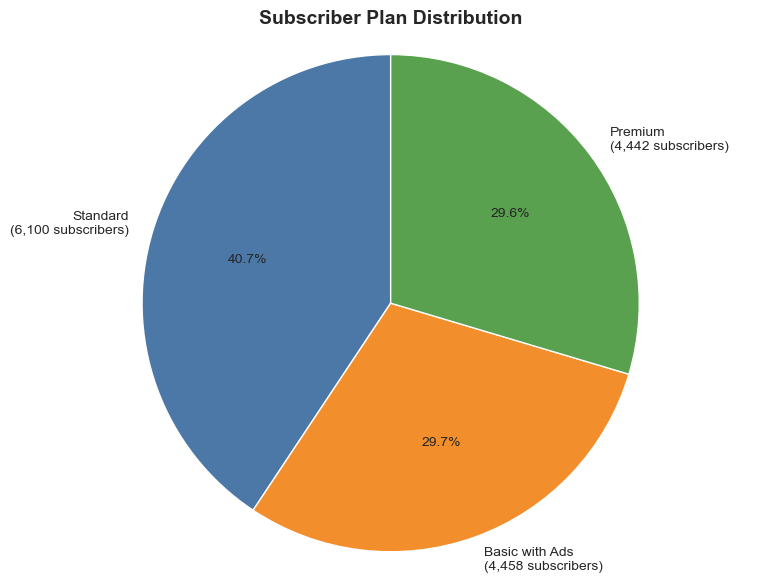

In [65]:
#Chart 6-Creating and save the pie chart


plan_labels = [
    f"{plan}\n({count:,} subscribers)"
    for plan, count in zip(
        plan_summary["plan_type"],
        plan_summary["subscriber_count"]
    )
]

plt.figure(figsize=(8, 6))

plt.pie(
    plan_summary["subscriber_count"],
    labels=plan_labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F28E2B", "#59A14F"],
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

plt.title(
    "Subscriber Plan Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.axis("equal")
plt.tight_layout()

plt.savefig(
    chart_folder / "06_subscriber_plan_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Standard was the most popular subscription plan, with 6,100 subscribers representing 40.7% of the total subscriber base. Basic with Ads had 4,458 subscribers (29.7%), while Premium had 4,442 subscribers (29.6%). The Basic with Ads and Premium plans were almost equally distributed, differing by only 16 subscribers.


In [66]:
#Chart 7: Device Usage.


#Identifying the device column

watch_history_df.columns.tolist()

['watch_id',
 'subscriber_id',
 'title_id',
 'watch_date',
 'device',
 'region',
 'content_duration_min',
 'watch_duration_min',
 'completion_pct',
 'completed',
 'duration_outlier_flag',
 'watch_month']

In [68]:
#“device usage” means the number of viewing sessions recorded on each device.

#Checking device categories and missing values

print("Unique devices:", watch_history_df["device"].nunique())
print("Missing device values:", watch_history_df["device"].isna().sum())

watch_history_df["device"].value_counts(dropna=False)

Unique devices: 6
Missing device values: 0


device
Smart TV           221446
Mobile             175605
Laptop              96408
Tablet              65276
Game Console        52322
Streaming Stick     38943
Name: count, dtype: int64

In [69]:
#Creating the device-usage summary

device_summary = (
    watch_history_df["device"]
    .value_counts()
    .rename_axis("device")
    .reset_index(name="viewing_sessions")
)

device_summary["share_percentage"] = (
    device_summary["viewing_sessions"]
    / device_summary["viewing_sessions"].sum()
    * 100
)

device_summary

,device,viewing_sessions,share_percentage
0,Smart TV,221446,34.068615
1,Mobile,175605,27.016154
2,Laptop,96408,14.832000
3,Tablet,65276,10.042462
4,Game Console,52322,8.049538
5,Streaming Stick,38943,5.991231


In [ ]:
# we have the summary is correct. Smart TV accounts for 34.1% of sessions, followed by Mobile at 27.0%.

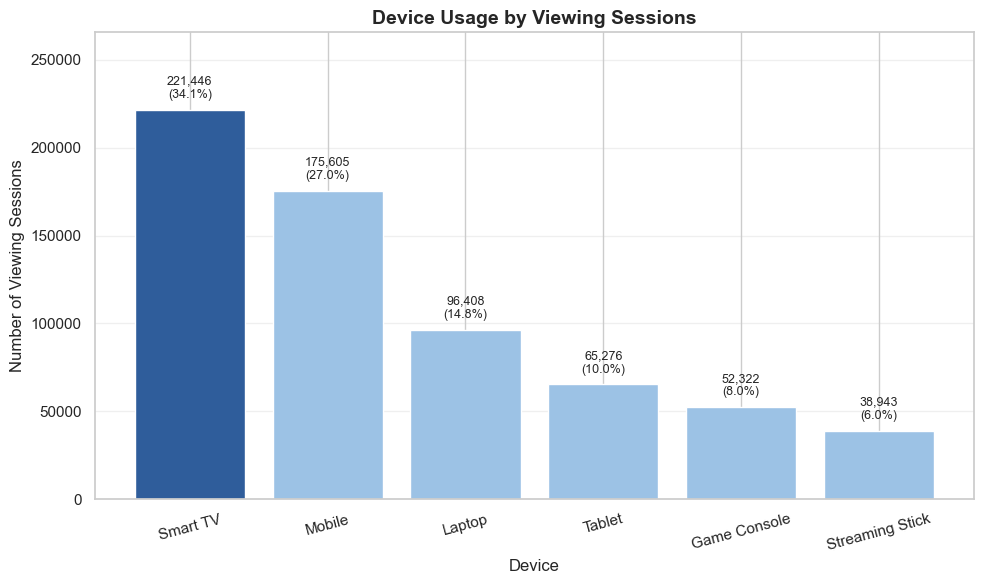

In [70]:
#Chart 7 - Creating and saving the device-usage bar chart


device_colors = ["#2F5D9B"] + ["#9CC2E5"] * (
    len(device_summary) - 1
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    device_summary["device"],
    device_summary["viewing_sessions"],
    color=device_colors
)

for bar, sessions, percentage in zip(
    bars,
    device_summary["viewing_sessions"],
    device_summary["share_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"{sessions:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Device Usage by Viewing Sessions",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Device")
ax.set_ylabel("Number of Viewing Sessions")
ax.set_ylim(0, device_summary["viewing_sessions"].max() * 1.20)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    chart_folder / "07_device_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Smart TV was the most frequently used device, accounting for 221,446 viewing sessions or 34.1% of the total. Mobile ranked second with 175,605 sessions (27.0%), meaning Smart TV and Mobile together generated 61.1% of all viewing sessions. Streaming Stick was the least-used device, contributing only 38,943 sessions or 6.0%.


In [71]:
#Chart 8: Subscriber Age Distribution.

#Identifying the age column

subscribers_df.columns.tolist()

['subscriber_id',
 'signup_date',
 'country',
 'region',
 'age',
 'gender',
 'plan_type',
 'monthly_price_usd',
 'household_size',
 'primary_device',
 'payment_method',
 'tenure_months',
 'is_active',
 'churn_date']

In [72]:
#Validating the age values

print("Missing age values:", subscribers_df["age"].isna().sum())
print("Minimum age:", subscribers_df["age"].min())
print("Maximum age:", subscribers_df["age"].max())

subscribers_df["age"].describe()

Missing age values: 0
Minimum age: 13
Maximum age: 85


count    15000.000000
mean        35.620267
std         12.532555
min         13.000000
25%         27.000000
50%         35.000000
75%         44.000000
max         85.000000
Name: age, dtype: float64

In [73]:
#Creating age groups

age_bins = [13, 20, 30, 40, 50, 60, 86]

age_labels = [
    "13–19",
    "20–29",
    "30–39",
    "40–49",
    "50–59",
    "60+"
]

subscribers_df["age_group"] = pd.cut(
    subscribers_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

subscribers_df["age_group"].value_counts().sort_index()

age_group
13–19    1666
20–29    3208
30–39    4494
40–49    3546
50–59    1593
60+       493
Name: count, dtype: int64

In [74]:
#Join age groups with watch history

age_watch_data = watch_history_df[
    ["watch_id", "subscriber_id", "watch_duration_min"]
].merge(
    subscribers_df[["subscriber_id", "age_group"]],
    on="subscriber_id",
    how="left",
    validate="many_to_one"
)

print("Watch-history rows:", len(watch_history_df))
print("Rows after joining:", len(age_watch_data))
print(
    "Rows with missing age group:",
    age_watch_data["age_group"].isna().sum()
)

age_watch_data.head()

Watch-history rows: 650000
Rows after joining: 650000
Rows with missing age group: 0


,watch_id,subscriber_id,watch_duration_min,age_group
0,1,SUB107630,826.7,30–39
1,2,SUB114773,1866.4,40–49
2,3,SUB106013,75.0,20–29
3,4,SUB100939,493.2,20–29
4,5,SUB107223,94.6,20–29


In [75]:
#Calculating viewing activity by age group

age_watch_summary = (
    age_watch_data
    .groupby("age_group", observed=False)
    .agg(
        viewing_sessions=("watch_id", "count"),
        watch_duration_minutes=("watch_duration_min", "sum")
    )
    .reset_index()
)

age_watch_summary["watch_hours"] = (
    age_watch_summary["watch_duration_minutes"] / 60
)

age_watch_summary["watch_hours_share"] = (
    age_watch_summary["watch_hours"]
    / age_watch_summary["watch_hours"].sum()
    * 100
)

age_watch_summary

,age_group,viewing_sessions,watch_duration_minutes,watch_hours,watch_hours_share
0,13–19,71402,22108053.2,3.684676e+05,11.053581
1,20–29,126421,38676584.0,6.446097e+05,19.337512
2,30–39,194557,60116974.9,1.001950e+06,30.057276
3,40–49,166096,51024125.9,8.504021e+05,25.511034
4,50–59,73140,22423455.0,3.737242e+05,11.211275
5,60+,18384,5658871.0,9.431452e+04,2.829321


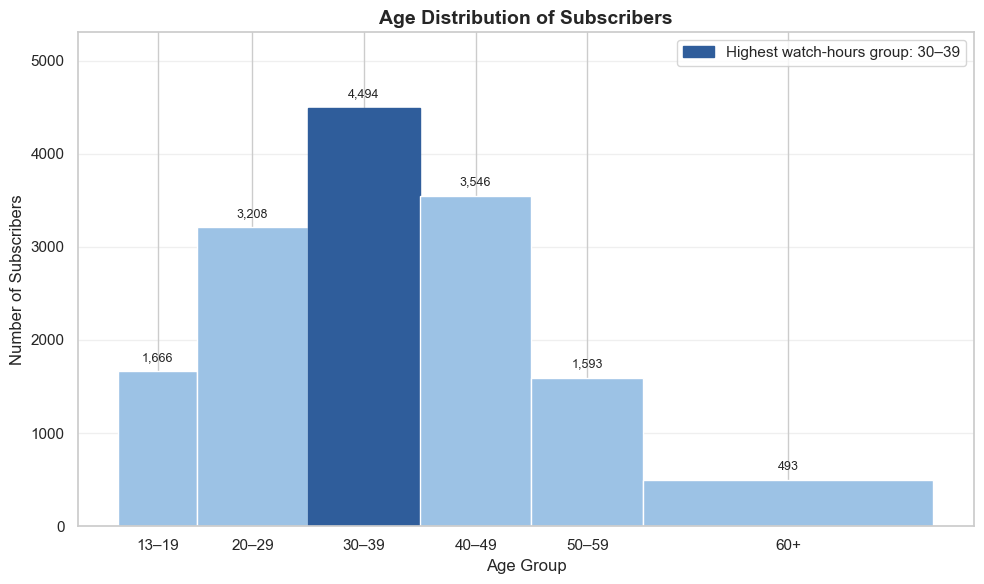

In [76]:
#Chart9-Creating and saving the age histogram


fig, ax = plt.subplots(figsize=(10, 6))

counts, bin_edges, bars = ax.hist(
    subscribers_df["age"],
    bins=age_bins,
    color="#9CC2E5",
    edgecolor="white"
)

bars[2].set_color("#2F5D9B")
bars[2].set_label("Highest watch-hours group: 30–39")

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(count):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

age_midpoints = [16.5, 25, 35, 45, 55, 73]

ax.set_xticks(age_midpoints)
ax.set_xticklabels(age_labels)

ax.set_title(
    "Age Distribution of Subscribers",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Subscribers")
ax.set_ylim(0, max(counts) * 1.18)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    chart_folder / "08_subscriber_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Observation

Subscribers aged 30–39 formed the largest age group, with 4,494 subscribers, and also generated the most viewing time—approximately 1,001,950 watch hours or 30.1% of the total. The 40–49 group ranked second with 3,546 subscribers and contributed approximately 25.5% of watch hours. Subscribers aged 60 and above formed the smallest group, with 493 subscribers and only 2.8% of total watch hours.


In [77]:
#Chart 9: Completion Rate by Genre


#Validate completion percentages

print(
    "Missing completion values:",
    watch_history_df["completion_pct"].isna().sum()
)

print(
    "Minimum completion percentage:",
    watch_history_df["completion_pct"].min()
)

print(
    "Maximum completion percentage:",
    watch_history_df["completion_pct"].max()
)

watch_history_df["completion_pct"].describe()

Missing completion values: 0
Minimum completion percentage: 1.0
Maximum completion percentage: 100.0


count    650000.000000
mean         65.310710
std          22.606162
min           1.000000
25%          49.200000
50%          68.300000
75%          84.100000
max         100.000000
Name: completion_pct, dtype: float64

In [78]:
#Join completion data with genre

genre_completion_data = watch_history_df[
    ["watch_id", "title_id", "completion_pct"]
].merge(
    titles_df[["title_id", "primary_genre"]],
    on="title_id",
    how="left",
    validate="many_to_one"
)

print("Watch-history rows:", len(watch_history_df))
print("Rows after joining:", len(genre_completion_data))

print(
    "Rows with missing genre:",
    genre_completion_data["primary_genre"].isna().sum()
)

genre_completion_data.head()

Watch-history rows: 650000
Rows after joining: 650000
Rows with missing genre: 0


,watch_id,title_id,completion_pct,primary_genre
0,1,TTL205207,93.1,Comedy
1,2,TTL204889,79.8,Drama
2,3,TTL206882,11.4,Comedy
3,4,TTL208849,98.6,Horror
4,5,TTL202529,67.1,Action


In [79]:
#Calculating the average completion rate by genre

genre_completion_summary = (
    genre_completion_data
    .groupby("primary_genre", as_index=False)
    .agg(
        average_completion_pct=("completion_pct", "mean"),
        viewing_sessions=("watch_id", "count")
    )
    .sort_values(
        "average_completion_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

genre_completion_summary["average_completion_pct"] = (
    genre_completion_summary["average_completion_pct"].round(2)
)

genre_completion_summary

,primary_genre,average_completion_pct,viewing_sessions
0,Musical,66.83,7425
1,Animation,66.38,29208
2,Stand-Up,66.32,7993
3,Fantasy,65.97,26407
4,Sci-Fi,65.79,33157
5,Mystery,65.56,18074
6,Crime,65.46,44153
7,Comedy,65.32,84455
8,Kids & Family,65.31,18338
9,Thriller,65.31,58589


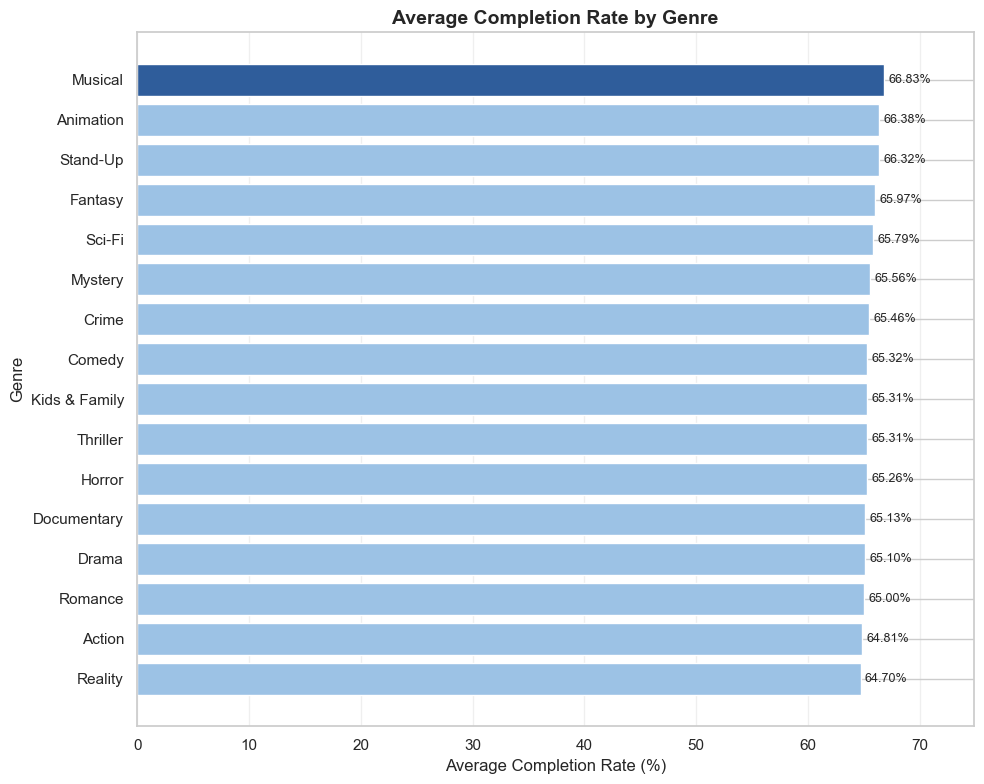

In [80]:
#Chart9-Creating and save the completion-rate chart


completion_plot_data = genre_completion_summary.sort_values(
    "average_completion_pct",
    ascending=True
)

completion_colors = ["#9CC2E5"] * len(completion_plot_data)
completion_colors[-1] = "#2F5D9B"

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    completion_plot_data["primary_genre"],
    completion_plot_data["average_completion_pct"],
    color=completion_colors
)

for bar, rate in zip(
    bars,
    completion_plot_data["average_completion_pct"]
):
    ax.text(
        rate + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Average Completion Rate by Genre",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Average Completion Rate (%)")
ax.set_ylabel("Genre")
ax.set_xlim(
    0,
    genre_completion_summary["average_completion_pct"].max() * 1.12
)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    chart_folder / "09_completion_rate_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Musical had the highest average completion rate at 66.83%, followed by Animation at 66.38% and Stand-Up at 66.32%. Reality recorded the lowest average completion rate at 64.70%. The difference between the highest and lowest genres was only 2.13 percentage points, indicating that completion behaviour was relatively consistent across genres.


In [81]:
#Chart 10—Review Sentiment Breakdown.

#Checking review sentiment values

print("Total review rows:", len(reviews_df))

print(
    "Missing sentiment values:",
    reviews_df["sentiment"].isna().sum()
)

reviews_df["sentiment"].value_counts(dropna=False)

Total review rows: 110000
Missing sentiment values: 0


sentiment
Positive    75007
Neutral     22759
Negative    12234
Name: count, dtype: int64

In [82]:
#Calculating sentiment percentages

sentiment_order = ["Positive", "Neutral", "Negative"]

sentiment_summary = (
    reviews_df["sentiment"]
    .value_counts()
    .reindex(sentiment_order)
    .rename_axis("sentiment")
    .reset_index(name="review_count")
)

sentiment_summary["share_percentage"] = (
    sentiment_summary["review_count"]
    / sentiment_summary["review_count"].sum()
    * 100
)

sentiment_summary

,sentiment,review_count,share_percentage
0,Positive,75007,68.188182
1,Neutral,22759,20.690000
2,Negative,12234,11.121818


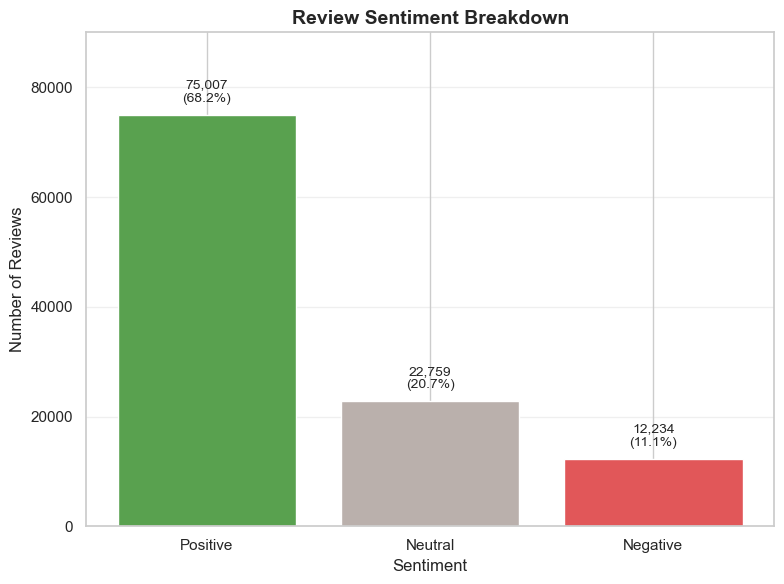

In [83]:
#Chart10-Creating and save the sentiment bar chart

sentiment_colors = ["#59A14F", "#BAB0AC", "#E15759"]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    sentiment_summary["sentiment"],
    sentiment_summary["review_count"],
    color=sentiment_colors
)

for bar, count, percentage in zip(
    bars,
    sentiment_summary["review_count"],
    sentiment_summary["share_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1800,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Review Sentiment Breakdown",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
ax.set_ylim(0, sentiment_summary["review_count"].max() * 1.20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    chart_folder / "10_review_sentiment_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Positive sentiment dominated the reviews, with 75,007 reviews representing 68.2% of the total. Neutral reviews accounted for 22,759 reviews (20.7%), while Negative reviews represented only 12,234 reviews (11.1%). Positive reviews were approximately 6.1 times more common than Negative reviews, indicating strongly favourable audience feedback.


## Phase 2 Final Validation

In [84]:
saved_chart_files = sorted(chart_folder.glob("*.png"))

print("Total PNG charts saved:", len(saved_chart_files))

for chart_file in saved_chart_files:
    print(chart_file.name)

Total PNG charts saved: 10
01_monthly_viewing_volume.png
02_monthly_watch_hours_yoy.png
03_genre_watch_hours_share.png
04_content_type_watch_hours.png
05_top_10_countries_watch_hours.png
06_subscriber_plan_distribution.png
07_device_usage.png
08_subscriber_age_distribution.png
09_completion_rate_by_genre.png
10_review_sentiment_breakdown.png
